# Algoritmo Genético para resolver un TSP

Inspirado en el trabajo: https://dl.acm.org/doi/fullHtml/10.1145/3581792.3581798



Si bien formular un TSP es sencillo e igualmente programarlo en un lenguaje como Python, el mismo tiene un gran inconveniente: la complejidad computacional a medida que el número n crece.

La cantidad de combinaciones pueden ser obtenidas de la combinación de los n nodos. Esto es $n!$

Esto involucra:

| $n$ | $n!$ |
|-----------|-----------|
|      5     |     120      |
|       10    |    $3.62\cdot 10^{6}$       |
|      20     |     $2.43\cdot 10^{18}$      |

Qué pasaría si intenamos resolver el problema anterior con 100 nodos?

In [1]:
#Importar librerias

import random
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import cdist
from ortools.linear_solver import pywraplp
import time

load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\zlib1.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\abseil_dll.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\utf8_validity.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\re2.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\libprotobuf.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\highs.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\ortools.dll...


In [2]:
def create_2d_points_df(n, seed):
  """
  Genera n puntos en un espacio 2D y los guarda en un dataframe de pandas.

  Args:
    n: número de puntos
    seed: semilla aleatoria usada para por hacer reproducible el código

  Returns:
    Un dataframe de Pandas con las columnas "x", e "y".
  """
  points_data = []
  random.seed(seed)
  for i in range(n):
    x = random.uniform(-100, 100)
    y = random.uniform(-100, 100)
    points_data.append({'x': x, 'y': y})

  df = pd.DataFrame(points_data)
  return df


def calculate_distance(df):
  """
 Toma un dataframe con columnas 'x' e 'y' y calcula las distancias euclídeas

  Args:
    df: dataframe de pandas con columnas 'x' e 'y'.

  Returns:
    Una matriz de distancias euclídeas.
  """
  coords = df[['x', 'y']].values
  distance_matrix = cdist(coords, coords, metric='euclidean')
  return distance_matrix

def plot_points(df):
  """
  Plotea los puntos generados por create_2d_points_df.

  Args:
    df: df: dataframe de pandas con columnas 'x' e 'y'.
  """
  x_coords = df['x'].tolist()
  y_coords = df['y'].tolist()

  plt.figure(figsize=(8, 8))
  plt.scatter(x_coords, y_coords)
  plt.title('Puntos en el espacio 2D')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.grid(True)
  plt.show()


def points_sub(points, i):
    """
    De una lista de numeros sustrae el numero i en una copia nueva.
    Se considera que poinla lista no tiene elementos duplicados (por ser lista de indices) y que i se encuentra en la lista.

    Args:
      points: lista de puntos.
      i: elemento a sustraer de la lista

    Returns:
      new: lista nueva similar a points pero sin el elemento i.
    """
    new = points.copy()
    new.remove(i)
    return new

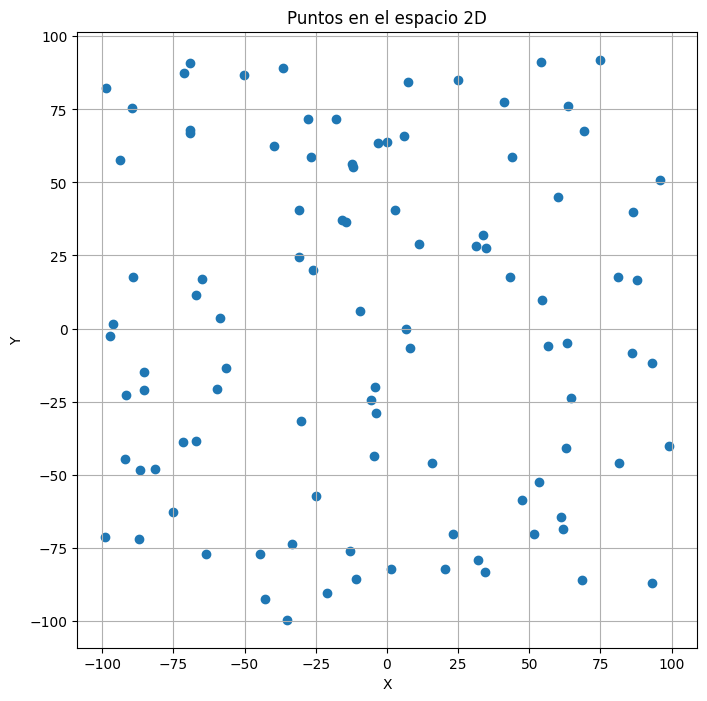

In [3]:
# Defino una semilla
seed = 1234

# Genero los puntos
puntos = create_2d_points_df(100, seed)

# Ploteo los puntos
plot_points(puntos)

# Calculo distancias
distancias = calculate_distance(puntos)

In [4]:
# Definimos el modelo
modelo_mtz = pywraplp.Solver.CreateSolver('SAT')

list_index_puntos = list(puntos.index)

# uso n como n-1 ya que arranco de indice 0 en la lista. Por esto en mtz no resto 1 ni en u_i
n = max(list_index_puntos)

# Definimos variables

x_ij={i:{j: modelo_mtz.IntVar(0,1,'x_'+str(i)+'_'+str(j)) for j in points_sub(list_index_puntos, i)} for i in list_index_puntos}
u_i = {i: modelo_mtz.IntVar(1,n,'u_'+str(i)) for i in points_sub(list_index_puntos, 0)}

# Definimos la función objetivo
obj_expr = sum(x_ij[i][j] * distancias[i][j] for i in list_index_puntos for j in points_sub(list_index_puntos, i))


#Restricciones:

#1
for j in list_index_puntos:
    modelo_mtz.Add(sum(x_ij[i][j] for i in points_sub(list_index_puntos, j)) == 1)

#2
for i in list_index_puntos:
    modelo_mtz.Add(sum(x_ij[i][j] for j in points_sub(list_index_puntos, i)) == 1)

#3
for i in points_sub(list_index_puntos, 0):
    for j in points_sub(points_sub(list_index_puntos, 0), i):
        modelo_mtz.Add(u_i[i] - u_i[j] + 1 <= n * (1- x_ij[i][j]))


# Solver
modelo_mtz.Minimize(obj_expr)

In [ ]:
inicio = time.time()
status = modelo_mtz.Solve()
fin = time.time()
print("Tiempo de ejecución:", fin - inicio, "segundos")

In [7]:
if status == pywraplp.Solver.OPTIMAL:
    print("Costo total:", modelo_mtz.Objective().Value())
else:
    print("No se encontró solución óptima.")

Costo total: 1530.4892402519954


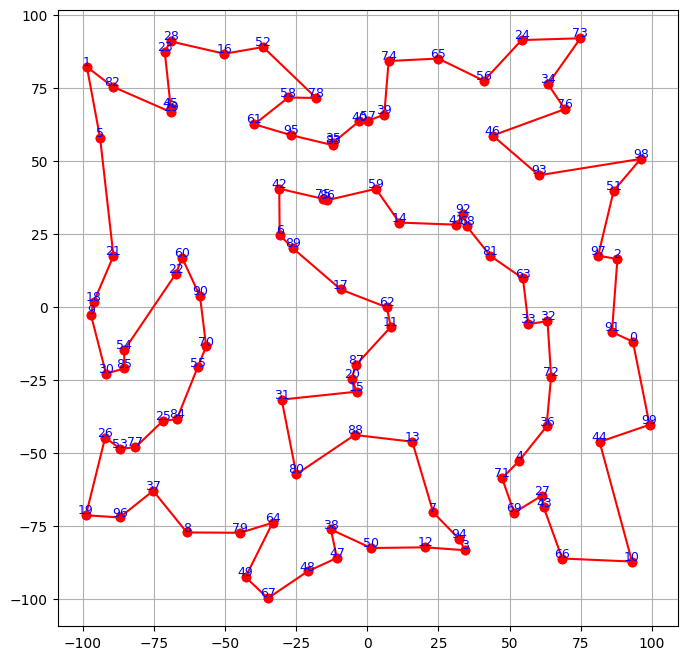

In [8]:
plt.figure(figsize=(8, 8))
plt.grid(True)
for i in list_index_puntos:
    for j in points_sub(list_index_puntos, i):
        if x_ij[i][j].SolutionValue() == 1:
            plt.plot(puntos.iloc[[i,j]]['x'], puntos.iloc[[i,j]]['y'], 'ro-')
            plt.text(puntos.iloc[i]['x'], puntos.iloc[i]['y'] + 0.5, str(i), ha='center', fontsize=9, color='blue')    
plt.show()

Esta ejecución llevó casi 12 minutos, con un costo mínimo encontrado de 1530.4892402519954

Se utilizó un computadora portatil con un i7-13620H, 16gb de RAM y una GPU NVIDIA GTX 4060 Laptop. Los tiempos pueden diferir según cada computadora.

# Algoritmo Genético (GA)

Con este ejemplo vemos que el tiempo computacional cambia significativamente al agregar más nodos. Por esto surgen heurísticas y metaheurísticas para encontrar buenos resultados sin el costo computacional abordado.

Dentro de este set de algoritmos, encontramos a los Algoritmos Genéticos (GA), inspirados en la evolución cromosómica de la naturaleza

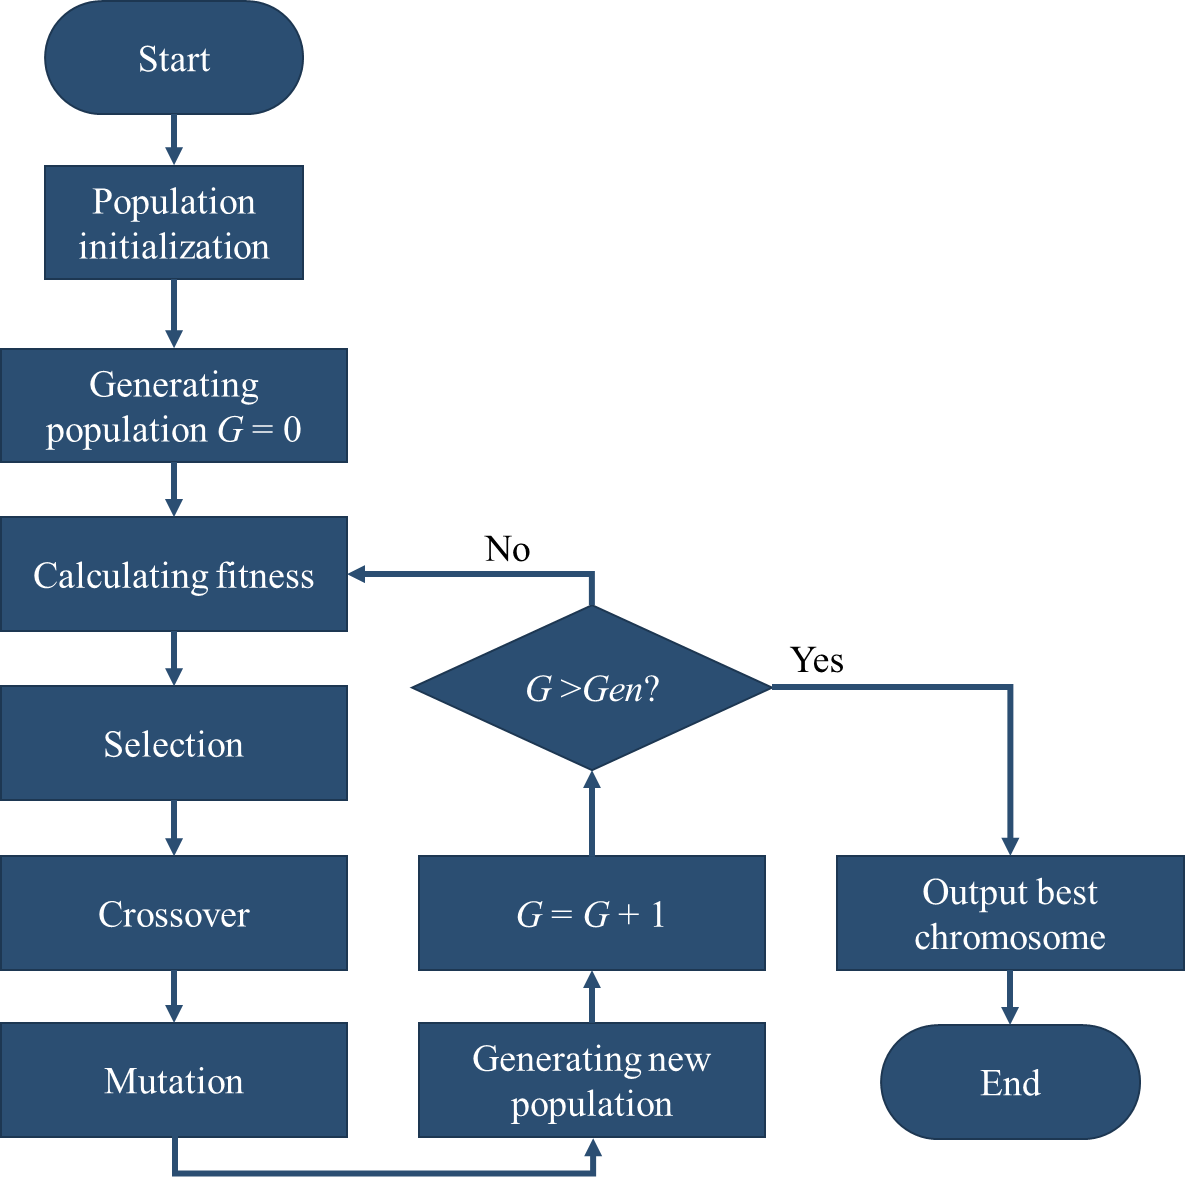

## Población inicial

Para generar la población inicial, pueden haber varios métodos. Para este caso creamos una función la cual genere una cantidad definida de secuencias completas de forma aleatoria

In [4]:
def secuencia_random(puntos, seed, cantidad=10):
    """
    Genera una secuencia aleatoria de indices de puntos.

    Args:
      puntos: dataframe de pandas con columnas 'x' e 'y'.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      Una lista con una secuencia aleatoria de indices de puntos.
    """
    secuencia = []
    for i in list(range(cantidad)):
      random.seed(seed + i)
      lista_indices = list(puntos.index)
      lista_indices = lista_indices[1:]
      random.shuffle(lista_indices)
      lista_indices = [0] + lista_indices
      secuencia.append(lista_indices)
      
    return secuencia

In [5]:
secs = secuencia_random(puntos, seed = 42, cantidad=30)

## Fitness

Como indica la literatura, debemos obtener una medida para calcular qué tan buenas son nuestras soluciones. Para eso usamos $1/distancia$, pero siendo que las mismas pueden estar dispersas (aunque las generamos en un espacio controlado), se procede a normalizarlas.

Para ello procedemos a hacer una min-max normalization

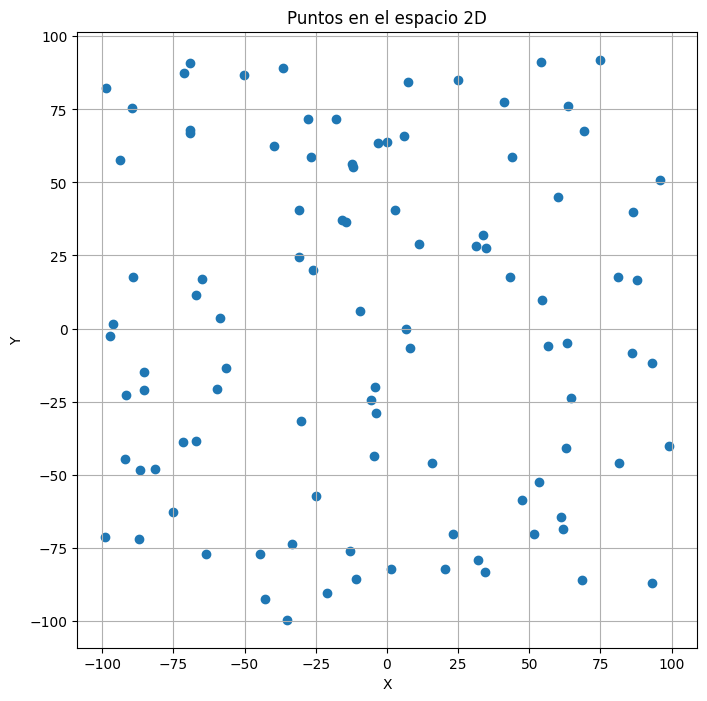

In [6]:
plot_points(puntos)


In [7]:
def normalize_points(df):
    """
    Normaliza las coordenadas x e y de un dataframe entre 0 y 1.

    Args:
      df: dataframe de pandas con columnas 'x' e 'y'.

    Returns:
      Un nuevo dataframe con las coordenadas normalizadas.
    """
    df_normalized = df.copy()
    df_normalized['x'] = (df['x'] - df['x'].min()) / (df['x'].max() - df['x'].min())
    df_normalized['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())
    return df_normalized

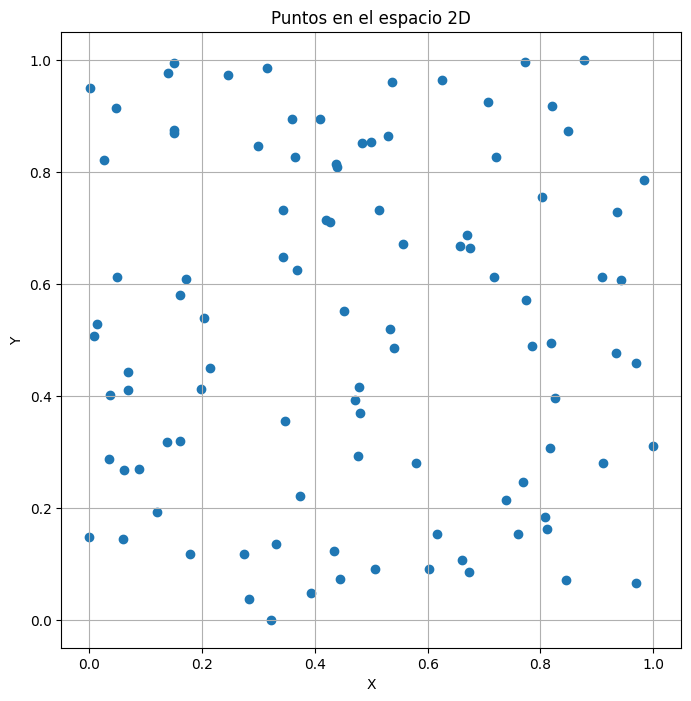

In [8]:
puntos_normalizados = normalize_points(puntos)
plot_points(puntos_normalizados)


Para calcular las distancias, creamos una función que admita los puntos en el espacio y calcule las distancias euclídeas

In [9]:
def calcular_distancia_total(secuencia, df):
    """
    Calcula la distancia total de un recorrido dado por una secuencia de índices sobre un DataFrame de puntos (x, y),
    incluyendo el regreso al punto inicial.

    Args:
      secuencia: lista de índices de puntos (orden del recorrido).
      df: DataFrame de pandas con columnas 'x' e 'y'.

    Returns:
      Distancia total del recorrido (float).
    """
    distancia_total = 0.0
    for i in range(len(secuencia) - 1):
        x1, y1 = df.iloc[secuencia[i]][['x', 'y']]
        x2, y2 = df.iloc[secuencia[i+1]][['x', 'y']]
        distancia_total += ((x2 - x1)**2 + (y2 - y1)**2)**0.5
    # Regreso al punto inicial
    x1, y1 = df.iloc[secuencia[-1]][['x', 'y']]
    x2, y2 = df.iloc[secuencia[0]][['x', 'y']]
    distancia_total += ((x2 - x1)**2 + (y2 - y1)**2)**0.5
    return distancia_total

Ejemplo, con la primer secuencia aleatoria:

In [10]:
calcular_distancia_total(secs[0], puntos_normalizados)

52.5197783857113

Ahora, realizamos una función para que dado una lista de secuencias, calculamos el fitness

In [11]:
population = pd.DataFrame({'secuencia': secs})

In [12]:
def calcular_fitness(population, df):
    """
    Calcula el fitness de cada secuencia en la población basado en la distancia total del recorrido.

    Args:
      population: DataFrame de pandas con una columna 'secuencia' que contiene listas de índices de puntos.
      df: DataFrame de pandas con columnas 'x' e 'y'.
    Returns:
      DataFrame de pandas con una columna 'fitness' que contiene el fitness de cada secuencia.
    """
    fitness_values = []
    for secuencia in population['secuencia']:
        distancia_total = calcular_distancia_total(secuencia, df)
        fitness = 1 / distancia_total  # Fitness es inversamente proporcional a la distancia total
        fitness_values.append(fitness)
    population['fitness'] = fitness_values
    return population

In [13]:
population = calcular_fitness(population, puntos_normalizados)
print(population.head())

                                           secuencia   fitness
0  [0, 73, 61, 91, 10, 34, 27, 2, 75, 16, 63, 80,...  0.019040
1  [0, 89, 69, 15, 28, 32, 67, 81, 68, 26, 61, 31...  0.018466
2  [0, 55, 32, 82, 47, 26, 64, 71, 11, 33, 27, 54...  0.018439
3  [0, 81, 78, 7, 12, 57, 72, 93, 95, 31, 36, 60,...  0.018755
4  [0, 78, 53, 31, 45, 86, 85, 35, 37, 57, 27, 42...  0.018123


## Selection

Para el proceso de selección, se eligen $p_r \cdot n $ individuos bajo algún criterio. En este caso usaremos los de mayor fitness por el método de la ruleta, donde a mayor fitness, mayor probabilidad de elección.



Primero obtenemos el numero de samples.

In [14]:
n = len(secs)
pr = 0.5

cant_individuos = (int(n*pr + 1) // 2) * 2 #usamos techo de pares para tener siempre un número par de individuos.

In [15]:
# Aumentamos population con el fitness/fitness_total

fitness_total = population['fitness'].sum()
population['fitness_normalized'] = population['fitness'] / fitness_total
print(population.head())

                                           secuencia   fitness  \
0  [0, 73, 61, 91, 10, 34, 27, 2, 75, 16, 63, 80,...  0.019040   
1  [0, 89, 69, 15, 28, 32, 67, 81, 68, 26, 61, 31...  0.018466   
2  [0, 55, 32, 82, 47, 26, 64, 71, 11, 33, 27, 54...  0.018439   
3  [0, 81, 78, 7, 12, 57, 72, 93, 95, 31, 36, 60,...  0.018755   
4  [0, 78, 53, 31, 45, 86, 85, 35, 37, 57, 27, 42...  0.018123   

   fitness_normalized  
0            0.034682  
1            0.033636  
2            0.033587  
3            0.034162  
4            0.033012  


In [114]:
# Generamos una funcion para la cual, dada una poblacion y la cantidad de individuos a seleccionar, devuelve los indices sin reposición de los individuos seleccionados por ruleta.

def seleccionar_individuos_ruleta_sin_reposicion(population, cant_individuos, seed = None):
    """
    Selecciona individuos de la población usando el método de selección por ruleta sin reposición.

    Args:
      population: DataFrame de pandas con una columna 'fitness_normalized' que contiene el fitness normalizado de cada secuencia.
      cant_individuos: número de individuos a seleccionar (debe ser par).
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      Lista de índices de los individuos seleccionados.
    """
    selected_indices = []
    population_copy = population.copy()
    
    for c in range(cant_individuos):
        fitness_total = population_copy['fitness'].sum()
        population_copy['fitness_normalized'] = population_copy['fitness'] / fitness_total
        cumulative_fitness = population_copy['fitness_normalized'].cumsum().tolist()
        
        if seed is not None:
          random.seed(seed)
        rand_values = [random.random() for _ in range(cant_individuos)]
        for index, cum_fit in enumerate(cumulative_fitness):
            if rand_values[c] <= cum_fit:
                selected_indices.append(int(population_copy.index[index]))
                population_copy = population_copy.drop(population_copy.index[index])
                break
                
    return selected_indices


In [115]:
selected_indices = seleccionar_individuos_ruleta_sin_reposicion(population, cant_individuos, seed=42)

In [116]:
# generamos pares aleatoriamente de individuos seleccionados para cruzamiento
def generar_pares_individuos(selected_indices, seed=None):
    """
    Genera pares aleatorios de individuos seleccionados para cruzamiento.

    Args:
      selected_indices: lista de índices de los individuos seleccionados.
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      Lista de tuplas, donde cada tupla contiene un par de índices de individuos.
    """
    indices_copy = selected_indices.copy()
    if seed is not None:
        random.seed(seed)
    random.shuffle(indices_copy)
    pares = []
    for i in range(0, len(indices_copy), 2):
        pares.append((indices_copy[i], indices_copy[i+1]))
    return pares

In [117]:
generar_pares_individuos(selected_indices, seed=42)

[(2, 1), (20, 27), (22, 9), (3, 13), (0, 8), (10, 18), (23, 16), (19, 7)]

## Crossover

Una vez obtenidos los pares a mutar, se genera el crossover de los mismos. Para ello primero se determina si va a habar crossover con el valor de $p_c$. Si p es mayor al umbral $p_c$, entonces realizamos el crossover.

Para este caso vamos a OX: Order Crossover

In [20]:
# Se genera cant_individuos numeros aleatorios para determinar los pi

def generar_numeros_aleatorios(cant_individuos, seed=None):
    """
    Genera una lista de números aleatorios entre 0 y 1 para determinar los puntos de cruce.

    Args:
      cant_individuos: número de individuos (debe ser par).
      seed: semilla aleatoria para reproducibilidad (opcional). 
    Returns:
      Lista de números aleatorios entre 0 y 1.
    """
    if seed is not None:
          random.seed(seed)
    rand_values = [random.random() for _ in range(cant_individuos)]
    return rand_values

In [21]:
generar_numeros_aleatorios(cant_individuos, seed=42)

[0.6394267984578837,
 0.025010755222666936,
 0.27502931836911926,
 0.22321073814882275,
 0.7364712141640124,
 0.6766994874229113,
 0.8921795677048454,
 0.08693883262941615,
 0.4219218196852704,
 0.029797219438070344,
 0.21863797480360336,
 0.5053552881033624,
 0.026535969683863625,
 0.1988376506866485,
 0.6498844377795232,
 0.5449414806032167]

In [22]:
# Ahora que tenemos los pares y los valores de pi, procedemos a generar el algoritmo de cruzamiento.

def cruzamiento_ordenado(parent1, parent2, seed=None):
    """
    Realiza el cruzamiento ordenado entre dos padres para generar dos hijos.

    Args:
      parent1: lista de índices del primer padre.
      parent2: lista de índices del segundo padre.

    Returns:
      Dos listas de índices que representan los hijos generados.
    """
    parent1 = parent1[1:]  # Excluyendo el punto de inicio fijo
    parent2 = parent2[1:]  # Excluyendo el punto de inicio fijo

    n = len(parent1)  # Excluyendo el punto de inicio fijo

    # Crear hijos vacíos
    child1 = [None] * n
    child2 = [None] * n

    # Seleccionar dos posiciones aleatoriamente
    if seed is not None:
        random.seed(seed)
    start = random.randint(0, n - 1)
    end = random.randint(0, n - 1)
    if start > end:
        start, end = end, start

    # Copiar la subsecuencia del padre al hijo
    child1[start:end + 1] = parent1[start:end + 1]
    child2[start:end + 1] = parent2[start:end + 1]
    # Rellenar los hijos con los elementos restantes del otro padre
    def fill_child(child, parent_other):
        current_index = (end + 1) % n
        for gene in parent_other:
            if gene not in child:
                child[current_index] = gene
                current_index = (current_index + 1) % n

    fill_child(child1, parent2)
    fill_child(child2, parent1)
    # Agregar el punto de inicio fijo al principio
    child1 = [0] + child1
    child2 = [0] + child2

    return child1, child2

Con esto podemos hacer una función que tomando los valores aleatorios generados y las secuencias, ejecute la función anterior.

In [133]:
def aplicar_cruzamiento(population, pares_individuos, rand_values, puntos, seed=None, pc = 0.1):
    """
    Aplica el cruzamiento ordenado a los pares de individuos seleccionados basándose en los valores aleatorios.

    Args:
      population: DataFrame de pandas con una columna 'secuencia' que contiene listas de índices de puntos.
      pares_individuos: lista de tuplas, donde cada tupla contiene un par de índices de individuos.
      rand_values: lista de números aleatorios entre 0 y 1 para determinar los puntos de cruce.
      puntos: DataFrame de pandas con columnas 'x' e 'y'.
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      DataFrame de pandas con la nueva población después del cruzamiento.
    """
    seeds_for_ox = None
    if seed is not None:
        seeds_for_ox = [seed + i for i in range(len(pares_individuos))]

    new_population = pd.DataFrame(columns=['secuencia'])
    for i, (idx1, idx2) in enumerate(pares_individuos):
        parent1 = population.loc[idx1, 'secuencia']
        parent2 = population.loc[idx2, 'secuencia']
        if rand_values[i] > pc:  # 1 - Probabilidad de cruzamiento
            child1, child2 = cruzamiento_ordenado(parent1, parent2, seed=seeds_for_ox[i] if seeds_for_ox else None)
            #elitist selection. Hago competir child1, child2 con sus padres y elijo los mejores.
            # Calculamos el fitness de los hijos
            fitness_child1 = calcular_fitness(pd.DataFrame({'secuencia': [child1]}), puntos)
            fitness_child2 = calcular_fitness(pd.DataFrame({'secuencia': [child2]}), puntos)
            fitness_parent1 = population.loc[idx1, 'fitness']
            fitness_parent2 = population.loc[idx2, 'fitness']

            # Seleccionamos los mejores
            all_secs_table = pd.DataFrame({
                'secuencia': [child1, child2, parent1, parent2],
                'fitness': [fitness_child1.loc[0, 'fitness'], fitness_child2.loc[0, 'fitness'], fitness_parent1, fitness_parent2]
            })
            all_secs_table = all_secs_table.sort_values(by='fitness', ascending=False).reset_index(drop=True)
            child1 = all_secs_table.loc[0, 'secuencia']
            child2 = all_secs_table.loc[1, 'secuencia']
        else:
            child1 = population.loc[idx1, 'secuencia']
            child2 = population.loc[idx2, 'secuencia']
            
            
            
        new_population = pd.concat([new_population, pd.DataFrame({'secuencia': [child1]})], ignore_index=True)
        new_population = pd.concat([new_population, pd.DataFrame({'secuencia': [child2]})], ignore_index=True)
    new_population = calcular_fitness(new_population, puntos)
    return new_population

In [128]:
oxs = aplicar_cruzamiento(population, generar_pares_individuos(selected_indices, seed=42), generar_numeros_aleatorios(cant_individuos, seed=42), puntos_normalizados, seed=42, pc=0.1)

In [129]:
print(oxs.head())

                                           secuencia   fitness
0  [0, 54, 92, 38, 4, 99, 21, 49, 23, 71, 66, 64,...  0.018893
1  [0, 97, 69, 60, 31, 5, 41, 37, 44, 76, 66, 13,...  0.019167
2  [0, 97, 69, 60, 31, 5, 41, 37, 44, 76, 66, 13,...  0.019167
3  [0, 79, 36, 1, 15, 89, 75, 83, 61, 32, 12, 59,...  0.019056
4  [0, 40, 29, 72, 82, 49, 95, 8, 13, 27, 85, 2, ...  0.018885


## Mutación (y rotación)

Para terminar con las operaciones básicas a realizar, se presenta el proceso de mutación y rotación. En el se eligen dos índices, y se rota el segmento del mismo. Esto es, si se tiene [0 1 2 3 4 5] y se aplica en de 1 a 3, la secuencias queda:

[0 | 1 2 3 | 4 5]

[0 | 3 2 1 | 4 5]

In [161]:
# Generamos una función que tome una secuencia y un número de semilla y retorne la misma mutada.

def mutacion_intercambio(secuencia, puntos, seed=None):
    """
    Realiza una mutación por intercambio en una secuencia dada.

    Args:
      secuencia: lista de índices de puntos (orden del recorrido).
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      Una nueva lista de índices que representa la secuencia mutada.
    """
    secuencia_mutada = secuencia.copy()
    n = len(secuencia_mutada)
    
    if seed is not None:
        random.seed(seed)
    
    # Seleccionar dos posiciones aleatorias para intercambiar
    idx1 = random.randint(1, n - 1)  # Evitar el punto de inicio fijo
    idx2 = random.randint(1, n - 1)
    
    # Asegurarse de que los índices sean diferentes
    while idx1 == idx2:
        idx2 = random.randint(1, n - 1)
    
    # Intercambiar los elementos en las posiciones seleccionadas
    secuencia_mutada[idx1], secuencia_mutada[idx2] = secuencia_mutada[idx2], secuencia_mutada[idx1]

    # Elitist selection: comparar la secuencia mutada con la original segun fitness y quedarse con la mejor
    fitness_original = calcular_fitness(pd.DataFrame({'secuencia': [secuencia]}), puntos).loc[0, 'fitness']
    fitness_mutada = calcular_fitness(pd.DataFrame({'secuencia': [secuencia_mutada]}), puntos).loc[0, 'fitness']

    if fitness_mutada < fitness_original:
        return secuencia
    else:    
        return secuencia_mutada

Para determinar si efectivamente se va a realizar la mutación, definimos que la misma se va a realizar si $p > p_m$

In [162]:
# Proceso de mutación

def aplicar_mutacion(population, puntos, pm = 0.0, seed=None):
    """
    Aplica la mutación por intercambio a la población basada en la probabilidad de mutación.

    Args:
      population: DataFrame de pandas con una columna 'secuencia' que contiene listas de índices de puntos.
      pm: probabilidad de mutación (entre 0 y 1).
      puntos: DataFrame de pandas con columnas 'x' e 'y'.
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      DataFrame de pandas con la población después de la mutación.
    """
    
    new_population = pd.DataFrame(columns=['secuencia'])
    for i, row in population.iterrows():
        secuencia = row['secuencia']
        if seed is not None:
            random.seed(seed + i)
        if random.random() > pm:
            secuencia_mutada = mutacion_intercambio(secuencia, puntos, seed=(seed + i) if seed is not None else None)
            new_population = pd.concat([new_population, pd.DataFrame({'secuencia': [secuencia_mutada]})], ignore_index=True)
        else:
            new_population = pd.concat([new_population, pd.DataFrame({'secuencia': [secuencia]})], ignore_index=True)
    new_population = calcular_fitness(new_population, puntos)
    return new_population

In [152]:
mutations = aplicar_mutacion(oxs, puntos_normalizados, pm=0.1, seed=42) # no olvidar los puntos normalizados

## Generación de la nueva población

In [ ]:
# Para generar la nueva población después de la mutación, debemos tomar lo mutado y lo no apartado en la selección por ruleta sin reposición.
new_population = mutations['secuencia'].copy()

In [100]:
non_selected_secs = [population.loc[i, 'secuencia'] for i in population.index if i not in selected_indices]

In [101]:
new_population = pd.concat([new_population, pd.DataFrame({'secuencia': non_selected_secs})])

In [104]:
new_population.reset_index(inplace=True, drop=True)

In [105]:
new_population

,secuencia
0,"[0, 54, 92, 38, 4, 99, 21, 49, 23, 71, 66, 64,..."
1,"[0, 97, 69, 60, 31, 5, 41, 37, 44, 76, 66, 13,..."
2,"[0, 90, 26, 14, 49, 41, 93, 30, 36, 85, 15, 8,..."
3,"[0, 79, 36, 1, 15, 89, 75, 83, 61, 32, 12, 59,..."
4,"[0, 40, 29, 72, 82, 49, 95, 8, 13, 27, 71, 2, ..."
5,"[0, 42, 50, 75, 80, 30, 15, 78, 68, 3, 73, 32,..."
6,"[0, 54, 22, 97, 94, 27, 87, 80, 25, 81, 84, 91..."
7,"[0, 48, 45, 25, 51, 22, 49, 89, 6, 74, 41, 46,..."
8,"[0, 20, 91, 72, 87, 29, 61, 89, 32, 82, 63, 80..."
9,"[0, 76, 12, 87, 14, 18, 29, 32, 15, 82, 17, 85..."


## Loop principal

Volviendo a la imagen del comienzo:

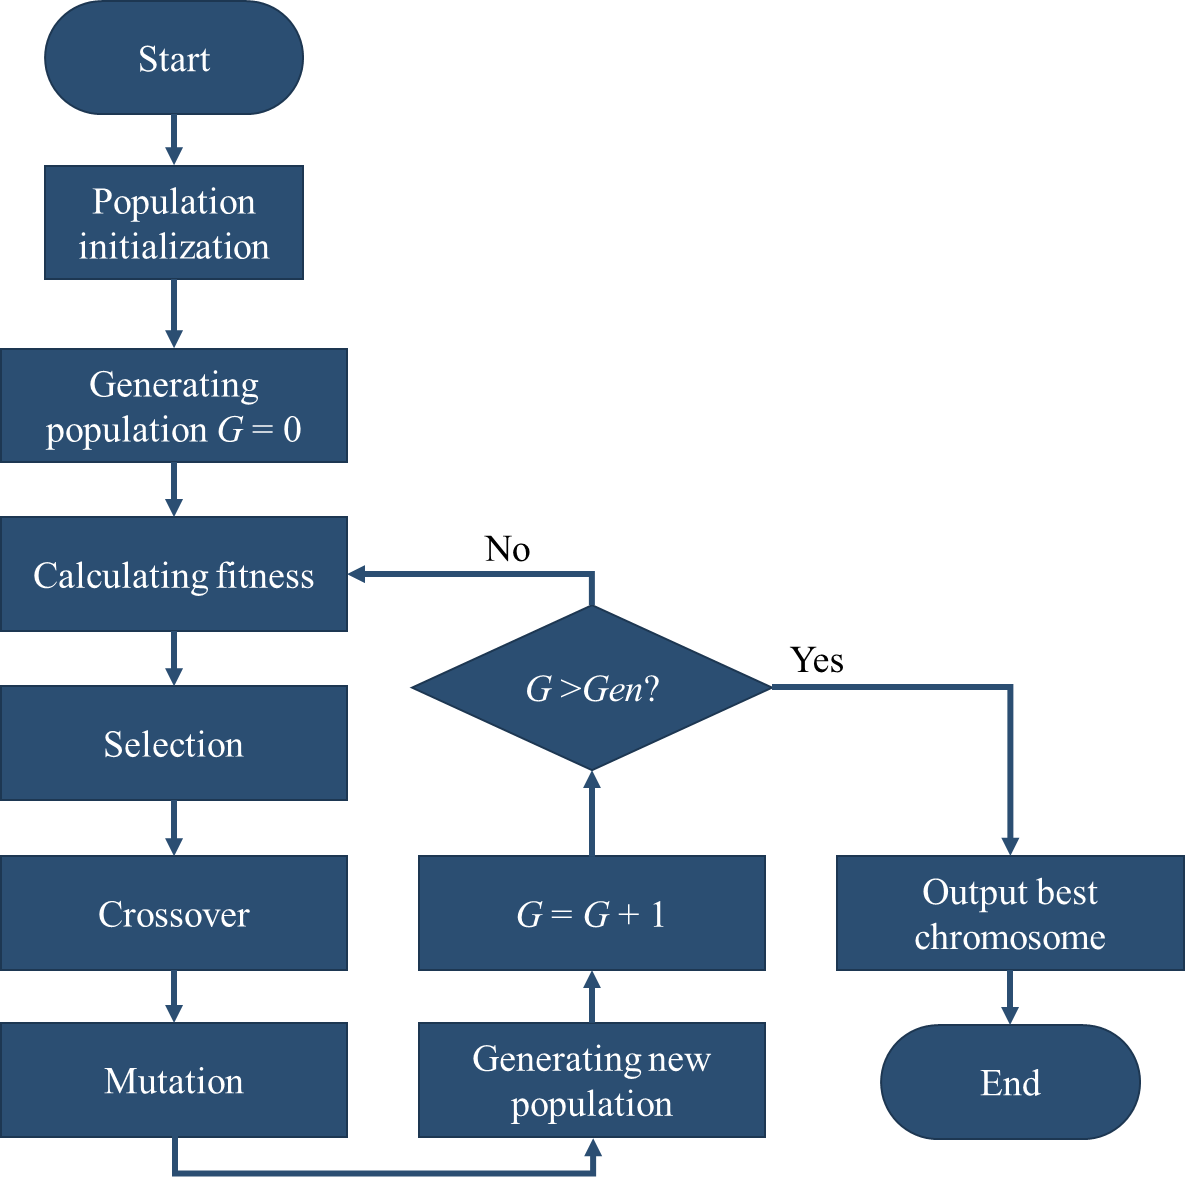

Creamos función de loop:

In [ ]:
def genetic_algorithm_tsp(puntos, population_size=30, generations=100, pc=0.1, pm=0.1, seed_sec=None, seed_selection=None, seed_pares=None, seed_ox=None, seed_mutation=None, seed=None):
    """
    Ejecuta el algoritmo genético para resolver el problema del viajante de comercio (TSP).

    Args:
      puntos: DataFrame de pandas con columnas 'x' e 'y'.
      population_size: tamaño de la población.
      generations: número de generaciones a ejecutar.
      pc: probabilidad de cruzamiento.
      pm: probabilidad de mutación.
      seed: semilla aleatoria para reproducibilidad (opcional).

    Returns:
      La mejor secuencia encontrada y su distancia total.
    """
    puntos_normalizados = normalize_points(puntos)
    secs = secuencia_random(puntos, seed=seed_sec if seed_sec is not None else 42, cantidad=population_size)
    population = pd.DataFrame({'secuencia': secs})
    population = calcular_fitness(population, puntos_normalizados)

    for gen in range(generations):
        # fitness_total = population['fitness'].sum()
        # population['fitness_normalized'] = population['fitness'] / fitness_total
        print(f"Generación {gen+1}/{generations}")

        cant_individuos = (int(population_size * 0.5 + 1) // 2) * 2  # Asegurar número par

        selected_indices = seleccionar_individuos_ruleta_sin_reposicion(population, cant_individuos, seed=seed_selection*(gen+1) if seed_selection is not None else 42)
        pares_individuos = generar_pares_individuos(selected_indices, seed=seed_pares*(gen+1) if seed_pares is not None else 42)
        rand_values = generar_numeros_aleatorios(cant_individuos, seed=seed*(gen+1) if seed is not None else 42)

        oxs = aplicar_cruzamiento(population, pares_individuos, rand_values, puntos_normalizados, seed=seed_ox if seed_ox is not None else 42, pc=pc)
        mutations = aplicar_mutacion(oxs, puntos_normalizados, pm=pm, seed=seed_mutation*(gen+1) if seed_mutation is not None else 42)

        non_selected_secs = [population.loc[i, 'secuencia'] for i in population.index if i not in selected_indices]
        new_population = mutations['secuencia'].copy()
        population = pd.concat([new_population, pd.DataFrame({'secuencia': non_selected_secs})])
        population.reset_index(inplace=True, drop=True)
        population = calcular_fitness(population, puntos_normalizados)

    best_index = population['fitness'].idxmax()
    best_sequence = population.loc[best_index, 'secuencia']
    best_distance = calcular_distancia_total(best_sequence, puntos)

    return best_sequence, best_distance

In [169]:
import datetime

now = datetime.datetime.now()
best_sequence, best_distance = genetic_algorithm_tsp(puntos, population_size=30, generations=1000, pc=0.1, pm=0.08, seed_sec=42, seed_selection=11, seed_pares=22, seed_ox=33, seed_mutation=44, seed=55)
end = datetime.datetime.now()
print("Tiempo total de ejecución:", end - now)
print(best_distance)

Generación 1/1000
Generación 2/1000
Generación 3/1000
Generación 4/1000
Generación 5/1000
Generación 6/1000
Generación 7/1000
Generación 8/1000
Generación 9/1000
Generación 10/1000
Generación 11/1000
Generación 12/1000
Generación 13/1000
Generación 14/1000
Generación 15/1000
Generación 16/1000
Generación 17/1000
Generación 18/1000
Generación 19/1000
Generación 20/1000
Generación 21/1000
Generación 22/1000
Generación 23/1000
Generación 24/1000
Generación 25/1000
Generación 26/1000
Generación 27/1000
Generación 28/1000
Generación 29/1000
Generación 30/1000
Generación 31/1000
Generación 32/1000
Generación 33/1000
Generación 34/1000
Generación 35/1000
Generación 36/1000
Generación 37/1000
Generación 38/1000
Generación 39/1000
Generación 40/1000
Generación 41/1000
Generación 42/1000
Generación 43/1000
Generación 44/1000
Generación 45/1000
Generación 46/1000
Generación 47/1000
Generación 48/1000
Generación 49/1000
Generación 50/1000
Generación 51/1000
Generación 52/1000
Generación 53/1000
Ge

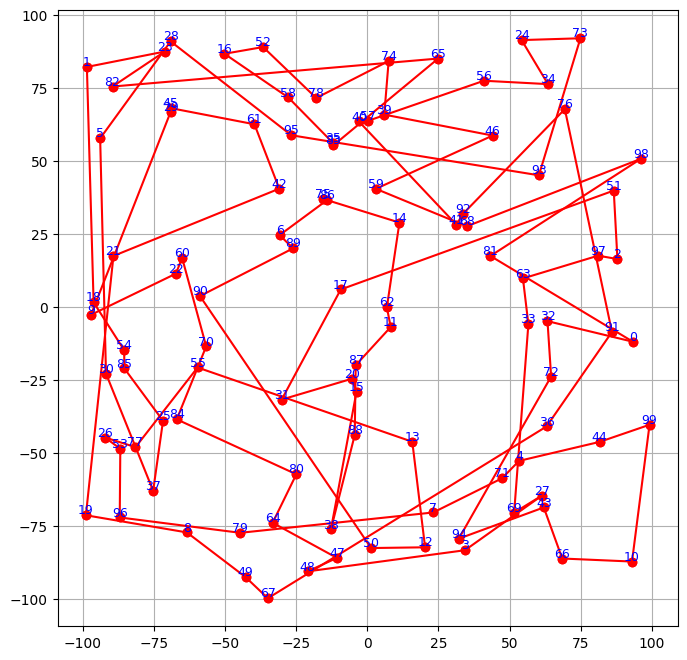

In [171]:
plt.figure(figsize=(8, 8))
plt.grid(True)
for i in range(len(best_sequence)):
    j = (i + 1) % len(best_sequence)
    plt.plot(puntos.iloc[[best_sequence[i], best_sequence[j]]]['x'], puntos.iloc[[best_sequence[i], best_sequence[j]]]['y'], 'ro-')
    plt.text(puntos.iloc[best_sequence[i]]['x'], puntos.iloc[best_sequence[i]]['y'] + 0.5, str(best_sequence[i]), ha='center', fontsize=9, color='blue')

Probando con varios números de generaciones vemos una tendencia a la convergencia. El problema es que aún es poco performante.

---------------TODO---------------------

acá abajo hay pruebas solo con mutación genética

In [8]:
def secuencia_random(puntos, seed, cantidad=10):
    """
    Genera una secuencia aleatoria de indices de puntos.

    Args:
      puntos: dataframe de pandas con columnas 'x' e 'y'.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      Una lista con una secuencia aleatoria de indices de puntos.
    """
    secuencia = []
    for i in list(range(cantidad)):
      random.seed(seed + i)
      lista_indices = list(puntos.index)
      lista_indices = lista_indices[1:]
      random.shuffle(lista_indices)
      lista_indices = [0] + lista_indices
      secuencia.append(lista_indices)
      
    return secuencia

In [5]:
secs = secuencia_random(puntos, 42, cantidad=30)

In [6]:
def calcular_distancia_total(secuencia, distancias):
    """
    Calcula la distancia total de una secuencia de indices de puntos.

    Args:
      secuencia: lista con una secuencia de indices de puntos.
      distancias: matriz de distancias euclídeas.

    Returns:
      La distancia total de la secuencia.
    """
    distancia_total = 0
    for i in range(len(secuencia) - 1):
        distancia_total += distancias[secuencia[i]][secuencia[i + 1]]
    distancia_total += distancias[secuencia[-1]][secuencia[0]]  # Volver al punto inicial
    return distancia_total

In [7]:
for i in range(len(secs)):
    print(f"Distancia total de la secuencia {i+1}: {calcular_distancia_total(secs[i], distancias)}")

Distancia total de la secuencia 1: 10218.796399795056
Distancia total de la secuencia 2: 10526.596981415856
Distancia total de la secuencia 3: 10569.995765383479
Distancia total de la secuencia 4: 10378.727453419731
Distancia total de la secuencia 5: 10730.408896810302
Distancia total de la secuencia 6: 10947.413080477532
Distancia total de la secuencia 7: 10661.179800205691
Distancia total de la secuencia 8: 11027.207162627643
Distancia total de la secuencia 9: 10842.510434982669
Distancia total de la secuencia 10: 10547.419645117196
Distancia total de la secuencia 11: 10285.326102046161
Distancia total de la secuencia 12: 9940.688702058887
Distancia total de la secuencia 13: 10565.102816584173
Distancia total de la secuencia 14: 10352.09913238319
Distancia total de la secuencia 15: 10470.021346625126
Distancia total de la secuencia 16: 11420.975156738752
Distancia total de la secuencia 17: 10711.155973823054
Distancia total de la secuencia 18: 11331.881442543954
Distancia total de la

creo una funcion para mutar secuencias

In [11]:
def mutar_secuencia(secuencia, seed):
    """ 
    Mutar una secuencia de indices de puntos intercambiando dos puntos aleatoriamente.

    Args:
      secuencia: lista con una secuencia de indices de puntos.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      Una nueva secuencia mutada.
    """
    random.seed(seed)
    nueva_secuencia = secuencia.copy()
    idx1, idx2 = random.sample(range(1, len(secuencia)), 2)  # Evitar el primer punto (índice 0)
    nueva_secuencia[idx1], nueva_secuencia[idx2] = nueva_secuencia[idx2], nueva_secuencia[idx1]
    return nueva_secuencia

creo una funcion para realizar el proceso evolutivo

In [12]:
def proceso_evolutivo(distancias, poblacion_inicial, generaciones, tasa_mutacion, seed):
    """
    Implementa un proceso evolutivo para optimizar la secuencia de puntos.

    Args:
      distancias: matriz de distancias euclídeas.
      poblacion_inicial: lista de listas con secuencias iniciales de indices de puntos.
      generaciones: número de generaciones a ejecutar.
      tasa_mutacion: probabilidad de mutación para cada secuencia.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      La mejor secuencia encontrada y su distancia total.
    """
    poblacion = poblacion_inicial.copy()
    mejor_secuencia = None
    mejor_distancia = float('inf')

    for gen in range(generaciones):
        nuevas_secuencias = []
        for secuencia in poblacion:
            # if random.random() < tasa_mutacion:
            #     secuencia_mutada = mutar_secuencia(secuencia, seed + gen)
            #     nuevas_secuencias.append(secuencia_mutada)
            # else:
            #     nuevas_secuencias.append(secuencia)
            
            secuencia_mutada = mutar_secuencia(secuencia, seed + gen) #hago que se muten todas las secuencias
            nuevas_secuencias.append(secuencia_mutada)
            

        poblacion = nuevas_secuencias

        for secuencia in poblacion:
            distancia = calcular_distancia_total(secuencia, distancias)
            if distancia < mejor_distancia:
                mejor_distancia = distancia
                mejor_secuencia = secuencia

    return mejor_secuencia, mejor_distancia

In [66]:
inicio = time.time()
mejor_secuencia, mejor_distancia = proceso_evolutivo(distancias, secs, generaciones=100000, tasa_mutacion=1, seed=42)
fin = time.time()
print("Tiempo de ejecución:", fin - inicio, "segundos")
print("Mejor secuencia encontrada:", mejor_secuencia)
print("Distancia total de la mejor secuencia:", mejor_distancia)

Tiempo de ejecución: 63.504587173461914 segundos
Mejor secuencia encontrada: [0, 33, 51, 8, 38, 30, 26, 43, 5, 70, 96, 82, 95, 36, 27, 55, 94, 77, 31, 84, 12, 44, 15, 29, 79, 67, 6, 21, 50, 39, 24, 57, 45, 1, 65, 58, 35, 76, 99, 69, 32, 88, 3, 54, 25, 89, 7, 75, 13, 81, 63, 60, 14, 4, 46, 66, 64, 19, 17, 83, 34, 2, 61, 49, 10, 18, 37, 90, 74, 78, 42, 68, 16, 52, 40, 23, 73, 56, 92, 86, 59, 20, 71, 93, 41, 53, 9, 85, 91, 72, 22, 28, 62, 47, 11, 48, 80, 87, 98, 97]
Distancia total de la mejor secuencia: 8365.86089350857


Este proceso tiene dos problemas. El primero es que se repiten muchas semillas, lo que no ayuda a la mezcla aleatoria. Por otro lado, si ya teniamos una secuencia buena y es mutada por una peor, empeora. Lo que se propone es afectar la seed multiplicativamente y además, evaluar cuál de las dos secuencias es la mejor, la original o la mutada, y se guarda la ganadora.

In [13]:
def proceso_evolutivo_mejorado(distancias, poblacion_inicial, generaciones, tasa_mutacion, seed):
    """
    Implementa un proceso evolutivo para optimizar la secuencia de puntos.

    Args:
      distancias: matriz de distancias euclídeas.
      poblacion_inicial: lista de listas con secuencias iniciales de indices de puntos.
      generaciones: número de generaciones a ejecutar.
      tasa_mutacion: probabilidad de mutación para cada secuencia.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      La mejor secuencia encontrada y su distancia total.
    """
    poblacion = poblacion_inicial.copy()
    mejor_secuencia = None
    mejor_distancia = float('inf')

    for gen in range(generaciones):
        nuevas_secuencias = []
        factor = 0
        for secuencia in poblacion:
            factor += 1
            # if random.random() < tasa_mutacion:
            #     secuencia_mutada = mutar_secuencia(secuencia, seed + gen)
            #     nuevas_secuencias.append(secuencia_mutada)
            # else:
            #     nuevas_secuencias.append(secuencia)
            
            secuencia_mutada = mutar_secuencia(secuencia, seed * gen * factor)
            distancia_mutada = calcular_distancia_total(secuencia_mutada, distancias)
            distancia_original = calcular_distancia_total(secuencia, distancias)
            if distancia_mutada < distancia_original:
              nuevas_secuencias.append(secuencia_mutada)
            else:
              nuevas_secuencias.append(secuencia)

        poblacion = nuevas_secuencias
        
    # lo muevo al final total siempre llegan las mismas secuencias y para no recalcular tantas veces
    for secuencia in poblacion:
        distancia = calcular_distancia_total(secuencia, distancias)
        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_secuencia = secuencia

    return mejor_secuencia, mejor_distancia

In [11]:
inicio = time.time()
mejor_secuencia, mejor_distancia = proceso_evolutivo_mejorado(distancias, secs, generaciones=100000, tasa_mutacion=1, seed=42)
fin = time.time()
print("Tiempo de ejecución:", fin - inicio, "segundos")
print("Mejor secuencia encontrada:", mejor_secuencia)
print("Distancia total de la mejor secuencia:", mejor_distancia)

Tiempo de ejecución: 114.24502682685852 segundos
Mejor secuencia encontrada: [0, 91, 72, 36, 62, 17, 90, 61, 52, 16, 29, 60, 22, 54, 85, 30, 25, 84, 55, 70, 11, 33, 32, 76, 73, 24, 34, 93, 92, 59, 35, 83, 86, 75, 89, 6, 95, 58, 78, 40, 57, 39, 74, 65, 56, 46, 68, 41, 14, 42, 45, 23, 28, 1, 82, 5, 21, 18, 9, 26, 53, 77, 37, 64, 48, 80, 31, 87, 20, 15, 88, 38, 50, 12, 7, 94, 3, 69, 27, 43, 66, 10, 99, 44, 4, 71, 19, 96, 8, 79, 49, 67, 47, 13, 81, 63, 97, 51, 98, 2]
Distancia total de la mejor secuencia: 2386.0047256498474


En menos de 2 minutos, conseguimos una muy buena primera aproximación

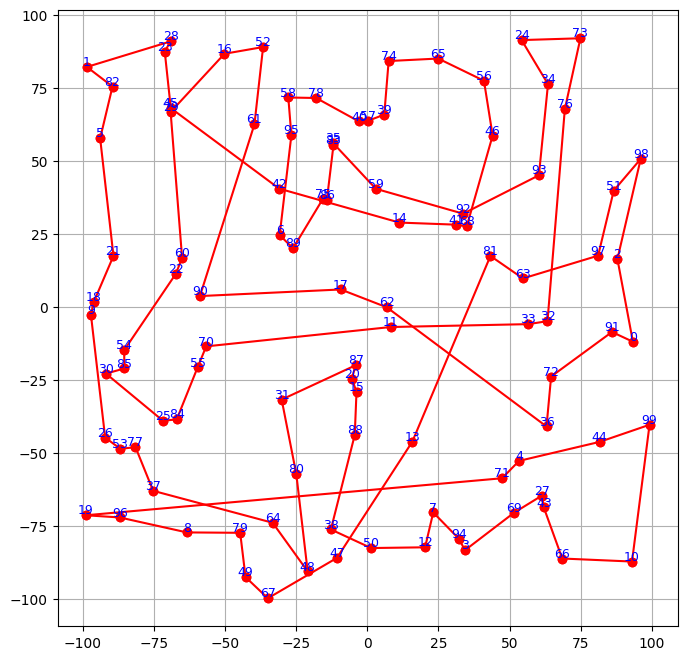

In [12]:
plt.figure(figsize=(8, 8))
plt.grid(True)
for i in range(len(mejor_secuencia)):
    j = (i + 1) % len(mejor_secuencia)
    plt.plot(puntos.iloc[[mejor_secuencia[i], mejor_secuencia[j]]]['x'], puntos.iloc[[mejor_secuencia[i], mejor_secuencia[j]]]['y'], 'ro-')
    plt.text(puntos.iloc[mejor_secuencia[i]]['x'], puntos.iloc[mejor_secuencia[i]]['y'] + 0.5, str(mejor_secuencia[i]), ha='center', fontsize=9, color='blue')

Claramente, aún falta mejorar. Pero llegamos a un resultado más que aceptable.

Vamos a evaluar a continuación, como cambia el resultado a medida que agregamos más generaciones

In [31]:
def show_secuencia_evolucion(dic_distancias, puntos):
    """
    Muestra la evolución de la secuencia de puntos a lo largo de las generaciones.

    Args:
      dic_distancias: diccionario con claves como generaciones y valores como tuplas (secuencia, distancia).
      puntos: dataframe de pandas con columnas 'x' e 'y'.
    """
    import matplotlib.pyplot as plt

    from IPython.display import clear_output

    # Parameters
    generaciones_plot = sorted(dic_distancias.keys())
    pause_secs = 0.1  # tiempo entre frames (ajustable)

    # fijo límites para evitar zoom entre frames
    xmin, xmax = puntos['x'].min(), puntos['x'].max()
    ymin, ymax = puntos['y'].min(), puntos['y'].max()
    xpad = (xmax - xmin) * 0.05
    ypad = (ymax - ymin) * 0.05

    for gen in generaciones_plot:
        seq = list(dic_distancias[gen][0])  # secuencia en ese checkpoint
        # preparar secuencia cerrada
        seq_loop = seq + [seq[0]]

        clear_output(wait=True)  # borra el plot anterior en la salida de la celda
        plt.figure(figsize=(8, 8))
        plt.title(f"Generación {gen} — Distancia: {float(dic_distancias[gen][1]):.2f}")
        plt.scatter(puntos['x'], puntos['y'], s=20, color='black')

        # dibujar la ruta
        xs = puntos.loc[seq_loop, 'x'].values
        ys = puntos.loc[seq_loop, 'y'].values
        plt.plot(xs, ys, 'ro-', linewidth=1, markersize=4)

        # opcional: numerar en cada punto el orden en la secuencia (pequeño)
        for order, idx in enumerate(seq):
            plt.text(puntos.at[idx, 'x'], puntos.at[idx, 'y'] + 0.6, str(order), 
                    ha='center', fontsize=7, color='blue')

        plt.xlim(xmin - xpad, xmax + xpad)
        plt.ylim(ymin - ypad, ymax + ypad)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.pause(pause_secs)

    # dejar el último plot visible (ya lo está tras el loop)

In [15]:
def proceso_evolutivo_mejorado_historial(distancias, poblacion_inicial, check_list, seed):
    """
    Implementa un proceso evolutivo para optimizar la secuencia de puntos.

    Args:
      distancias: matriz de distancias euclídeas.
      poblacion_inicial: lista de listas con secuencias iniciales de indices de puntos.
      check_list: lista con el numero de generaciones a evaluar
      tasa_mutacion: probabilidad de mutación para cada secuencia.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      La mejor secuencia encontrada y su distancia total.
    """
    generaciones = max(check_list)
    poblacion = poblacion_inicial.copy()
    mejor_secuencia = None
    mejor_distancia = float('inf')
    dic_distancias = {}

    for gen in range(generaciones+1):
        nuevas_secuencias = []
        factor = 0
        for secuencia in poblacion:
            factor += 1
            # if random.random() < tasa_mutacion:
            #     secuencia_mutada = mutar_secuencia(secuencia, seed + gen)
            #     nuevas_secuencias.append(secuencia_mutada)
            # else:
            #     nuevas_secuencias.append(secuencia)
            
            secuencia_mutada = mutar_secuencia(secuencia, seed * gen * factor)
            distancia_mutada = calcular_distancia_total(secuencia_mutada, distancias)
            distancia_original = calcular_distancia_total(secuencia, distancias)
            if distancia_mutada < distancia_original:
              nuevas_secuencias.append(secuencia_mutada)
            else:
              nuevas_secuencias.append(secuencia)

        poblacion = nuevas_secuencias

        if gen in check_list:
            for secuencia in poblacion:
                distancia = calcular_distancia_total(secuencia, distancias)
                if distancia < mejor_distancia:
                    mejor_distancia = distancia
                    mejor_secuencia = secuencia
            dic_distancias[gen] = (mejor_secuencia, mejor_distancia)
        
    # lo muevo al final total siempre llegan las mismas secuencias y para no recalcular tantas veces
    # for secuencia in poblacion:
    #     distancia = calcular_distancia_total(secuencia, distancias)
    #     if distancia < mejor_distancia:
    #         mejor_distancia = distancia
    #         mejor_secuencia = secuencia

    return dic_distancias

In [17]:
check_list = list(range(1000, 500001, 1000))

In [15]:
inicio = time.time()
dic_distancias = proceso_evolutivo_mejorado_historial(distancias, secs, check_list, 42)
fin = time.time()

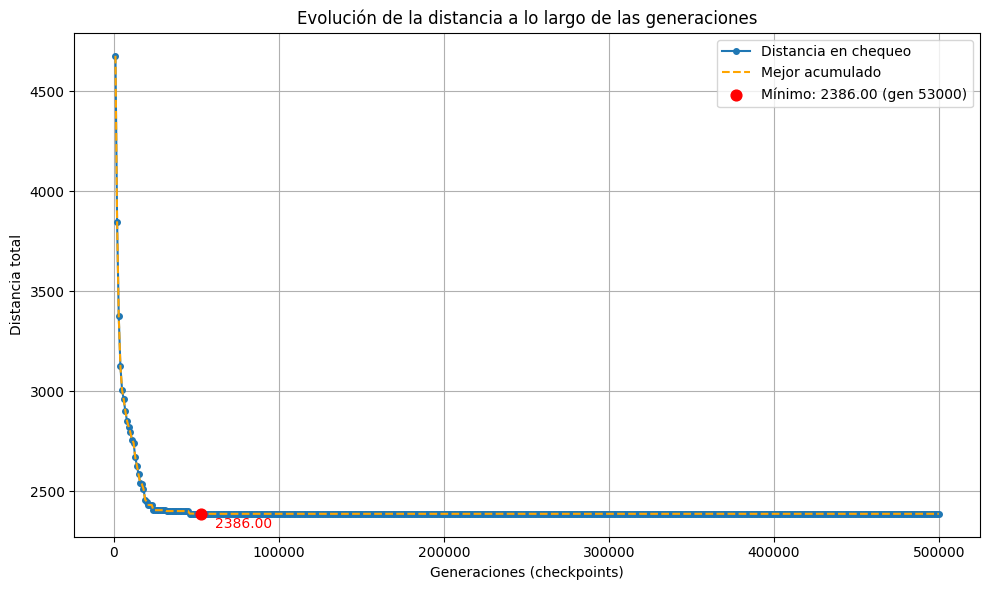

In [17]:
# Plotea la evolución de las distancias guardadas en dic_distancias
generaciones = sorted(dic_distancias.keys())
dist_vals = [float(dic_distancias[g][1]) for g in generaciones]

# Mejor acumulada hasta cada punto (best so far)
best_so_far = []
current_best = float('inf')
for d in dist_vals:
    if d < current_best:
        current_best = d
    best_so_far.append(current_best)

plt.figure(figsize=(10, 6))
plt.plot(generaciones, dist_vals, marker='o', markersize=4, linestyle='-', label='Distancia en chequeo')
plt.plot(generaciones, best_so_far, linestyle='--', color='orange', label='Mejor acumulado')

# Anotar el mejor global
min_idx = min(range(len(dist_vals)), key=lambda i: dist_vals[i])
min_gen = generaciones[min_idx]
min_dist = dist_vals[min_idx]
plt.scatter([min_gen], [min_dist], color='red', s=60, zorder=5, label=f'Mínimo: {min_dist:.2f} (gen {min_gen})')
plt.annotate(f"{min_dist:.2f}", xy=(min_gen, min_dist), xytext=(10, -10), textcoords='offset points', color='red')

plt.xlabel('Generaciones (checkpoints)')
plt.ylabel('Distancia total')
plt.title('Evolución de la distancia a lo largo de las generaciones')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Como vemos, parece ser que no hay mejora significativa una vez pasamos el gen 53000, y sabemos que aún podemos mejorar. Esto podria darse (a checkear) porque estamos trabajando solo sobre un par en secuencia y lo puede hacer restrictivo. Vamos entonces a hacer una ultima prueba, en la cual damos la posibilidad de mutar sobre más de un valor en la secuencia.

In [34]:
def mutar_secuencia_mejorada(secuencia, seed):
    """ 
    Mutar una secuencia de indices de puntos intercambiando dos puntos aleatoriamente.

    Args:
      secuencia: lista con una secuencia de indices de puntos.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      Una nueva secuencia mutada.
    """
    random.seed(seed)
    cantidad_max_mutaciones = max(1, len(secuencia) // 20)  # Al menos una mutación
    cantidad_mutaciones = random.randint(1, cantidad_max_mutaciones)
    for _ in range(cantidad_mutaciones):
        seed += 1
        secuencia = mutar_secuencia(secuencia, seed)

    nueva_secuencia = secuencia.copy()
    return nueva_secuencia

In [35]:
def proceso_evolutivo_mejorado_historial_2(distancias, poblacion_inicial, check_list, seed):
    """
    Implementa un proceso evolutivo para optimizar la secuencia de puntos.

    Args:
      distancias: matriz de distancias euclídeas.
      poblacion_inicial: lista de listas con secuencias iniciales de indices de puntos.
      check_list: lista con el numero de generaciones a evaluar
      tasa_mutacion: probabilidad de mutación para cada secuencia.
      seed: semilla aleatoria usada para por hacer reproducible el código

    Returns:
      La mejor secuencia encontrada y su distancia total.
    """
    generaciones = max(check_list)
    poblacion = poblacion_inicial.copy()
    mejor_secuencia = None
    mejor_distancia = float('inf')
    dic_distancias = {}

    for gen in range(generaciones+1):
        nuevas_secuencias = []
        factor = 0
        for secuencia in poblacion:
            factor += 1
            # if random.random() < tasa_mutacion:
            #     secuencia_mutada = mutar_secuencia(secuencia, seed + gen)
            #     nuevas_secuencias.append(secuencia_mutada)
            # else:
            #     nuevas_secuencias.append(secuencia)
            
            secuencia_mutada = mutar_secuencia_mejorada(secuencia, seed * gen * factor)
            distancia_mutada = calcular_distancia_total(secuencia_mutada, distancias)
            distancia_original = calcular_distancia_total(secuencia, distancias)
            if distancia_mutada < distancia_original:
              nuevas_secuencias.append(secuencia_mutada)
            else:
              nuevas_secuencias.append(secuencia)

        poblacion = nuevas_secuencias

        if gen in check_list:
            for secuencia in poblacion:
                distancia = calcular_distancia_total(secuencia, distancias)
                if distancia < mejor_distancia:
                    mejor_distancia = distancia
                    mejor_secuencia = secuencia
            dic_distancias[gen] = (mejor_secuencia, mejor_distancia)
        
    # lo muevo al final total siempre llegan las mismas secuencias y para no recalcular tantas veces
    # for secuencia in poblacion:
    #     distancia = calcular_distancia_total(secuencia, distancias)
    #     if distancia < mejor_distancia:
    #         mejor_distancia = distancia
    #         mejor_secuencia = secuencia

    return dic_distancias

In [36]:
inicio = time.time()
dic_distancias = proceso_evolutivo_mejorado_historial_2(distancias, secs, check_list, 42)
fin = time.time()

In [37]:
print("Tiempo de ejecución:", fin - inicio, "segundos")

Tiempo de ejecución: 862.1956803798676 segundos


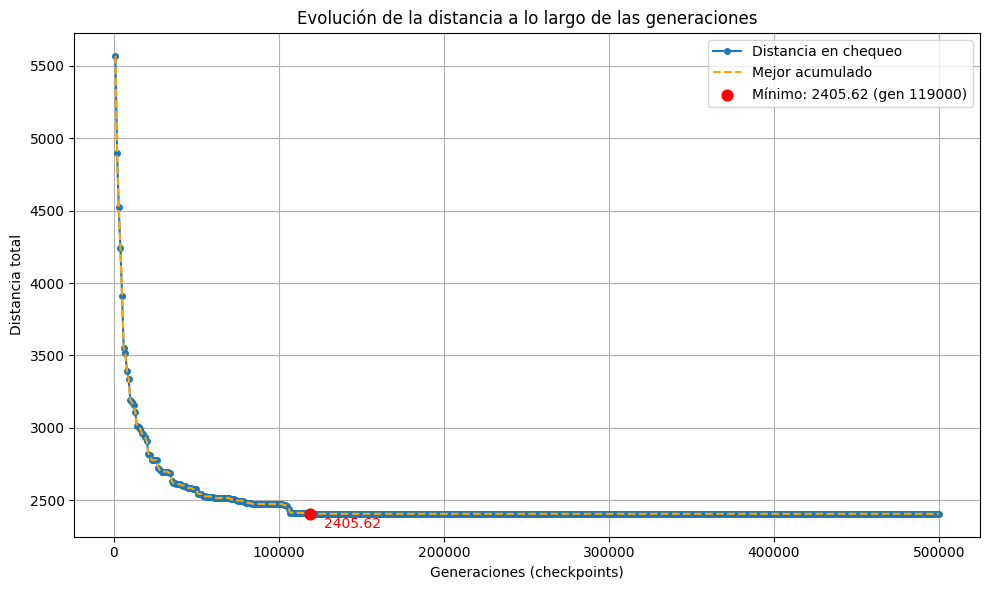

In [39]:
# Plotea la evolución de las distancias guardadas en dic_distancias
generaciones = sorted(dic_distancias.keys())
dist_vals = [float(dic_distancias[g][1]) for g in generaciones]

# Mejor acumulada hasta cada punto (best so far)
best_so_far = []
current_best = float('inf')
for d in dist_vals:
    if d < current_best:
        current_best = d
    best_so_far.append(current_best)

plt.figure(figsize=(10, 6))
plt.plot(generaciones, dist_vals, marker='o', markersize=4, linestyle='-', label='Distancia en chequeo')
plt.plot(generaciones, best_so_far, linestyle='--', color='orange', label='Mejor acumulado')

# Anotar el mejor global
min_idx = min(range(len(dist_vals)), key=lambda i: dist_vals[i])
min_gen = generaciones[min_idx]
min_dist = dist_vals[min_idx]
plt.scatter([min_gen], [min_dist], color='red', s=60, zorder=5, label=f'Mínimo: {min_dist:.2f} (gen {min_gen})')
plt.annotate(f"{min_dist:.2f}", xy=(min_gen, min_dist), xytext=(10, -10), textcoords='offset points', color='red')

plt.xlabel('Generaciones (checkpoints)')
plt.ylabel('Distancia total')
plt.title('Evolución de la distancia a lo largo de las generaciones')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
show_secuencia_evolucion(dic_distancias, puntos)

Ahora lo mismo, pero con más secuencias iniciales

In [8]:
secs = secuencia_random(puntos, 42, cantidad=100)

In [9]:
mejor_distancia = float('inf')
mejor_secuencia = None
for i in range(len(secs)):
    distancia = calcular_distancia_total(secs[i], distancias)
    if distancia < mejor_distancia:
        mejor_distancia = distancia
        mejor_secuencia = secs[i]
print("Mejor secuencia encontrada:", mejor_secuencia)
print("Distancia total de la mejor secuencia:", mejor_distancia)

Mejor secuencia encontrada: [0, 57, 95, 86, 38, 26, 80, 47, 77, 41, 30, 88, 15, 50, 25, 3, 99, 13, 52, 69, 96, 9, 44, 56, 87, 61, 75, 90, 23, 54, 53, 55, 72, 32, 78, 84, 45, 29, 20, 71, 39, 97, 18, 66, 22, 21, 31, 93, 33, 60, 36, 2, 51, 11, 42, 67, 79, 89, 1, 5, 64, 43, 73, 8, 28, 37, 65, 16, 4, 91, 7, 24, 68, 81, 17, 14, 59, 83, 49, 6, 19, 70, 10, 48, 35, 63, 34, 98, 94, 58, 46, 82, 40, 76, 74, 85, 62, 12, 92, 27]
Distancia total de la mejor secuencia: 9587.47213139825


In [18]:
check_list = list(range(1000, 500001, 1000))

In [20]:
inicio = time.time()
dic_distancias = proceso_evolutivo_mejorado_historial(distancias, secs, check_list, 42)
fin = time.time()
print("Tiempo de ejecución:", fin - inicio, "segundos")

Tiempo de ejecución: 1881.873036146164 segundos


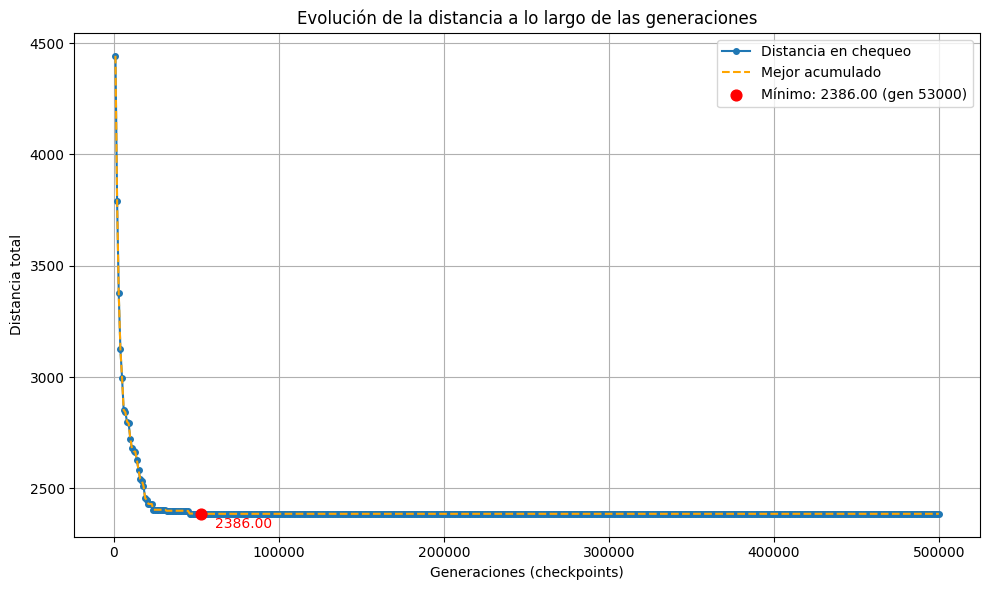

In [21]:
# Plotea la evolución de las distancias guardadas en dic_distancias
generaciones = sorted(dic_distancias.keys())
dist_vals = [float(dic_distancias[g][1]) for g in generaciones]

# Mejor acumulada hasta cada punto (best so far)
best_so_far = []
current_best = float('inf')
for d in dist_vals:
    if d < current_best:
        current_best = d
    best_so_far.append(current_best)

plt.figure(figsize=(10, 6))
plt.plot(generaciones, dist_vals, marker='o', markersize=4, linestyle='-', label='Distancia en chequeo')
plt.plot(generaciones, best_so_far, linestyle='--', color='orange', label='Mejor acumulado')

# Anotar el mejor global
min_idx = min(range(len(dist_vals)), key=lambda i: dist_vals[i])
min_gen = generaciones[min_idx]
min_dist = dist_vals[min_idx]
plt.scatter([min_gen], [min_dist], color='red', s=60, zorder=5, label=f'Mínimo: {min_dist:.2f} (gen {min_gen})')
plt.annotate(f"{min_dist:.2f}", xy=(min_gen, min_dist), xytext=(10, -10), textcoords='offset points', color='red')

plt.xlabel('Generaciones (checkpoints)')
plt.ylabel('Distancia total')
plt.title('Evolución de la distancia a lo largo de las generaciones')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
show_secuencia_evolucion(dic_distancias, puntos)

NameError: name 'show_secuencia_evolucion' is not defined